In [1]:
# =============================================================================
# DKTC 위협 대화 분류 — 2단계 분류 프로토타입
#
# 목적: 괴롭힘 내부 4개 클래스 경계 강화를 위해 문제를 분리
#
# Stage 1: 일반대화 vs 괴롭힘 (binary)
# Stage 2: 협박 / 갈취 / 직장내괴롭힘 / 기타괴롭힘 (4-class, harm-only)
#
# 비교 기준:
#   - 단일 5-class focal_epoch_5 (Macro F1: 0.9301)
#   - 2단계 파이프라인 합성 결과
#
# 기반 문서: dktc_model_improvement_runbook_2026-03-17_v2.md (Section 8.3A)
# 환경: Docker (py-gpu-env), RTX 5060 Ti 16GB, Python 3.10
# =============================================================================

In [2]:
# ============================================================================
# 00. 환경 설정 및 최적화
# ============================================================================
import sys, site, os
print("sys.executable =", sys.executable)
print("sys.prefix     =", sys.prefix)
print("site-packages  =", site.getsitepackages())
 
import transformers, datasets, evaluate, huggingface_hub, accelerate
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("evaluate:", evaluate.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("accelerate:", accelerate.__version__)
 
 
# %%
import os, time, gc, warnings, json
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import torch
 
# 재현성
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
 
from collections import Counter
from datasets import Dataset, DatasetDict
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
)
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
from torch.nn import CrossEntropyLoss
import torch.nn.functional as F
 
# --- CPU / GPU 최적화 ---
CPU_COUNT = os.cpu_count() or 4
CPU_THREADS = max(1, CPU_COUNT // 2)
 
os.environ["OMP_NUM_THREADS"] = str(CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(CPU_THREADS)
os.environ["TOKENIZERS_PARALLELISM"] = "true"
 
torch.set_num_threads(CPU_THREADS)
try:
    torch.set_num_interop_threads(max(1, min(4, CPU_THREADS // 2)))
except RuntimeError:
    pass
 
USE_CUDA = torch.cuda.is_available()
DEVICE = "cuda" if USE_CUDA else "cpu"
 
if USE_CUDA:
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
 
print("=" * 70)
print(f"PyTorch              : {torch.__version__}")
print(f"CUDA available       : {USE_CUDA}")
print(f"Device               : {DEVICE}")
print(f"CPU count            : {CPU_COUNT}")
print(f"CPU threads          : {CPU_THREADS}")
if USE_CUDA:
    props = torch.cuda.get_device_properties(0)
    free_mem, total_mem = torch.cuda.memory.mem_get_info(0)
    print(f"GPU name             : {props.name}")
    print(f"GPU count            : {torch.cuda.device_count()}")
    print(f"GPU memory(total)    : {props.total_memory / (1024**3):.2f} GB")
    print(f"GPU memory(free)     : {free_mem / (1024**3):.2f} GB")
print("=" * 70)

sys.executable = /usr/bin/python3
sys.prefix     = /usr
site-packages  = ['/usr/local/lib/python3.10/dist-packages', '/usr/lib/python3/dist-packages', '/usr/lib/python3.10/dist-packages']


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers: 5.3.0
datasets: 4.8.2
evaluate: 0.4.6
huggingface_hub: 1.7.1
accelerate: 1.13.0
PyTorch              : 2.10.0+cu128
CUDA available       : True
Device               : cuda
CPU count            : 20
CPU threads          : 10
GPU name             : NVIDIA GeForce RTX 5060 Ti
GPU count            : 1
GPU memory(total)    : 15.93 GB
GPU memory(free)     : 14.80 GB


In [3]:
# ============================================================================
# 01. 데이터 로드 + 2단계용 데이터셋 생성
# ============================================================================
MODEL_NAME = "klue/roberta-base"     # 한국어 RoBERTa (111M params)
MAX_LENGTH = 512                     # 97% 커버리지 (전처리 품질 리포트 기준)
 
# --- 5-class 라벨 체계 (원본) ---
LABEL_NAMES_5 = ["협박", "갈취", "직장내괴롭힘", "기타괴롭힘", "일반대화"]
#                  0      1       2            3          4
 
# --- Stage 1 라벨 체계 (binary) ---
LABEL_NAMES_BIN = ["일반대화", "괴롭힘"]
#                    0          1
 
# --- Stage 2 라벨 체계 (harm-only 4-class) ---
LABEL_NAMES_HARM = ["협박", "갈취", "직장내괴롭힘", "기타괴롭힘"]
#                    0      1       2            3
 
 
# --- 전처리된 CSV 로드 ---
train_df = pd.read_csv("data/train_processed_260317_n_1000.csv")
val_df = pd.read_csv("data/val_processed_260317_n_1000.csv")
 
print(f"원본 데이터: Train {len(train_df)}, Val {len(val_df)}")
print(f"\n원본 학습 클래스 분포:")
print(train_df["label_name"].value_counts().to_string())
print(f"\n원본 검증 클래스 분포:")
print(val_df["label_name"].value_counts().to_string())
 
 
# ============================================================================
# Stage 1용 binary 데이터셋
# - label_bin = 0 → 일반대화 (원래 label == 4)
# - label_bin = 1 → 괴롭힘   (원래 label in {0,1,2,3})
# ============================================================================
train_bin = train_df.copy()
val_bin = val_df.copy()
 
train_bin["label_bin"] = (train_bin["label"] != 4).astype(int)
val_bin["label_bin"] = (val_bin["label"] != 4).astype(int)
 
print("\n" + "=" * 70)
print("Stage 1 — Binary 데이터셋")
print("=" * 70)
print(f"Train: {len(train_bin)}")
for name, val in zip(LABEL_NAMES_BIN, [0, 1]):
    cnt_tr = (train_bin["label_bin"] == val).sum()
    cnt_va = (val_bin["label_bin"] == val).sum()
    print(f"  {name} (label_bin={val}): train {cnt_tr}, val {cnt_va}")
 
 
# ============================================================================
# Stage 2용 harm-only 4-class 데이터셋
# - 일반대화(label==4) 제거
# - 라벨 0~3 그대로 유지 (재매핑 불필요)
# ============================================================================
train_harm = train_df[train_df["label"] != 4].copy()
val_harm = val_df[val_df["label"] != 4].copy()
 
# --- 라벨 범위 검증 (0~3인지 확인) ---
assert train_harm["label"].min() == 0, f"Stage2 train 라벨 최솟값 이상: {train_harm['label'].min()}"
assert train_harm["label"].max() == 3, f"Stage2 train 라벨 최댓값 이상: {train_harm['label'].max()}"
assert val_harm["label"].min() == 0, f"Stage2 val 라벨 최솟값 이상: {val_harm['label'].min()}"
assert val_harm["label"].max() == 3, f"Stage2 val 라벨 최댓값 이상: {val_harm['label'].max()}"
assert set(train_harm["label"].unique()) == {0, 1, 2, 3}, "Stage2 train에 0~3 클래스가 모두 존재해야 함"
assert set(val_harm["label"].unique()) == {0, 1, 2, 3}, "Stage2 val에 0~3 클래스가 모두 존재해야 함"
 
print("\n" + "=" * 70)
print("Stage 2 — Harm-only 4-class 데이터셋")
print("=" * 70)
print(f"Train: {len(train_harm)}, Val: {len(val_harm)}")
for name, val in zip(LABEL_NAMES_HARM, [0, 1, 2, 3]):
    cnt_tr = (train_harm["label"] == val).sum()
    cnt_va = (val_harm["label"] == val).sum()
    print(f"  {name} (label={val}): train {cnt_tr}, val {cnt_va}")
 
# --- 데이터 누수 방지 확인 ---
# Stage 1과 Stage 2 모두 동일한 원본 train/val split에서 파생
print(f"\n[데이터 누수 검증]")
print(f"  원본 train index 범위: {train_df.index.min()} ~ {train_df.index.max()}")
print(f"  원본 val index 범위:   {val_df.index.min()} ~ {val_df.index.max()}")
print(f"  Stage1 bin train 크기: {len(train_bin)} (원본과 동일: {len(train_bin) == len(train_df)})")
print(f"  Stage2 harm train 크기: {len(train_harm)} (= 원본 - 일반대화: {len(train_df) - (train_df['label'] == 4).sum()})")
print("  ✓ 동일 split 기준 유지 확인")

원본 데이터: Train 3942, Val 969

원본 학습 클래스 분포:
label_name
기타 괴롭힘 대화      808
일반 대화          800
협박 대화          778
갈취 대화          778
직장 내 괴롭힘 대화    778

원본 검증 클래스 분포:
label_name
기타 괴롭힘 대화      202
일반 대화          200
갈취 대화          195
직장 내 괴롭힘 대화    194
협박 대화          178

Stage 1 — Binary 데이터셋
Train: 3942
  일반대화 (label_bin=0): train 800, val 200
  괴롭힘 (label_bin=1): train 3142, val 769

Stage 2 — Harm-only 4-class 데이터셋
Train: 3142, Val: 769
  협박 (label=0): train 778, val 178
  갈취 (label=1): train 778, val 195
  직장내괴롭힘 (label=2): train 778, val 194
  기타괴롭힘 (label=3): train 808, val 202

[데이터 누수 검증]
  원본 train index 범위: 0 ~ 3941
  원본 val index 범위:   0 ~ 968
  Stage1 bin train 크기: 3942 (원본과 동일: True)
  Stage2 harm train 크기: 3142 (= 원본 - 일반대화: 3142)
  ✓ 동일 split 기준 유지 확인


In [4]:
# ============================================================================
# 02. 토크나이저 + HuggingFace Dataset 변환
# ============================================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
 
def preprocess_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH, padding=False)
 
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if USE_CUDA else None,
    return_tensors="pt",
)
 
 
# --- Stage 1 토크나이징 ---
print("Stage 1 (binary) 토크나이징...")
ds_bin = DatasetDict({
    "train": Dataset.from_pandas(
        train_bin[["text", "label_bin"]].rename(columns={"label_bin": "labels"}).reset_index(drop=True)
    ),
    "validation": Dataset.from_pandas(
        val_bin[["text", "label_bin"]].rename(columns={"label_bin": "labels"}).reset_index(drop=True)
    ),
})
 
tok_bin = ds_bin.map(
    preprocess_function, batched=True, batch_size=1000,
    num_proc=max(1, min(8, CPU_THREADS)),
    remove_columns=["text"], desc="Tokenizing (Stage1)"
)
tok_bin.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
 
 
# --- Stage 2 토크나이징 ---
print("Stage 2 (harm-only 4-class) 토크나이징...")
ds_harm = DatasetDict({
    "train": Dataset.from_pandas(
        train_harm[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True)
    ),
    "validation": Dataset.from_pandas(
        val_harm[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True)
    ),
})
 
tok_harm = ds_harm.map(
    preprocess_function, batched=True, batch_size=1000,
    num_proc=max(1, min(8, CPU_THREADS)),
    remove_columns=["text"], desc="Tokenizing (Stage2)"
)
tok_harm.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
 
print("\n토크나이징 완료")
print(f"  Stage 1: train {len(tok_bin['train'])}, val {len(tok_bin['validation'])}")
print(f"  Stage 2: train {len(tok_harm['train'])}, val {len(tok_harm['validation'])}")

Setting TOKENIZERS_PARALLELISM=false for forked processes.


Stage 1 (binary) 토크나이징...


Tokenizing (Stage1) (num_proc=8): 100%|██████████| 3942/3942 [00:03<00:00, 1235.43 examples/s]
Setting TOKENIZERS_PARALLELISM=false for forked processes.
Tokenizing (Stage1) (num_proc=8): 100%|██████████| 969/969 [00:00<00:00, 2826.46 examples/s]
Setting TOKENIZERS_PARALLELISM=false for forked processes.


Stage 2 (harm-only 4-class) 토크나이징...


Tokenizing (Stage2) (num_proc=8): 100%|██████████| 3142/3142 [00:00<00:00, 6948.62 examples/s]
Setting TOKENIZERS_PARALLELISM=false for forked processes.
Tokenizing (Stage2) (num_proc=8): 100%|██████████| 769/769 [00:00<00:00, 2309.15 examples/s]


토크나이징 완료
  Stage 1: train 3942, val 969
  Stage 2: train 3142, val 769


In [5]:
# ============================================================================
# 03. 평가 지표 + FocalLossTrainer 정의
# ============================================================================
import evaluate as ev
 
acc_metric = ev.load("accuracy")
f1_metric  = ev.load("f1")
 
 
def compute_metrics_binary(eval_pred):
    """Stage 1 (binary) 평가: accuracy, binary F1, 클래스별 recall"""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":      acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_binary":     f1_metric.compute(predictions=preds, references=labels, average="binary")["f1"],
        "f1_macro":      f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
        "recall_normal": recall_score(labels, preds, pos_label=0, average="binary", zero_division=0),
        "recall_harm":   recall_score(labels, preds, pos_label=1, average="binary", zero_division=0),
    }
 
 
def compute_metrics_harm(eval_pred):
    """Stage 2 (4-class harm) 평가: accuracy, macro F1, weighted F1"""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro":    f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
        "f1_weighted": f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }
 
 
# --- Focal Loss 구현 ---
# 수학적 정의:
#   FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
#   p_t = softmax(logit)[true_class]
#
# gamma > 0 → 쉬운 샘플(p_t가 큰)의 기여를 줄임
# alpha_t   → 클래스별 가중치 (class imbalance 보정)
#
# 참고: Lin et al., "Focal Loss for Dense Object Detection", ICCV 2017
 
class FocalLoss(torch.nn.Module):
    def __init__(self, gamma=2.0, weight=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.weight = weight          # class weight tensor (alpha)
        self.reduction = reduction
 
    def forward(self, logits, targets):
        # log_softmax → 수치 안정성
        log_probs = F.log_softmax(logits, dim=-1)               # (B, C)
        # gather: 정답 클래스의 log_prob 추출
        log_pt = log_probs.gather(dim=-1, index=targets.unsqueeze(-1)).squeeze(-1)  # (B,)
        pt = log_pt.exp()                                       # p_t = exp(log_pt)
 
        # focal weight: (1 - p_t)^gamma
        focal_weight = (1.0 - pt) ** self.gamma                 # (B,)
 
        # class weight (alpha_t)
        if self.weight is not None:
            alpha_t = self.weight.gather(dim=0, index=targets)   # (B,)
            focal_weight = focal_weight * alpha_t
 
        # loss = -alpha_t * (1-p_t)^gamma * log(p_t)
        loss = -focal_weight * log_pt                            # (B,)
 
        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss
 
 
class FocalLossTrainer(Trainer):
    """Focal Loss를 사용하는 커스텀 Trainer"""
    def __init__(self, *args, focal_gamma=2.0, focal_weight=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.focal_loss_fn = FocalLoss(
            gamma=focal_gamma,
            weight=focal_weight,
        )
 
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = self.focal_loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss
 
 
print("평가 지표 + FocalLossTrainer 정의 완료")

평가 지표 + FocalLossTrainer 정의 완료


In [6]:
# ============================================================================
# 04. Stage 1 — 일반대화 vs 괴롭힘 (Binary Classification)
# ============================================================================
# 설정: 런북 8.3A 권장 — 우선 CrossEntropy, 3 epoch, lr 2e-5
#
# 핵심 관찰 지표: 괴롭힘 recall
#   → Stage 1에서 괴롭힘을 일반대화로 놓치면 Stage 2에 넘어가지 못함
# ============================================================================
print("\n" + "=" * 70)
print(" Stage 1 — 일반대화 vs 괴롭힘 (Binary)")
print("=" * 70)
 
NUM_LABELS_S1 = 2
 
# --- Class Weight (Stage 1) ---
cw_s1 = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_LABELS_S1),
    y=train_bin["label_bin"].values
)
cw_s1_tensor = torch.tensor(cw_s1, dtype=torch.float)
if USE_CUDA:
    cw_s1_tensor = cw_s1_tensor.to("cuda")
print(f"Stage 1 class weights: {dict(zip(LABEL_NAMES_BIN, cw_s1.round(3)))}")
 
# --- 모델 초기화 ---
model_s1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS_S1
)
 
supports_bf16 = USE_CUDA and torch.cuda.is_bf16_supported()
 
args_s1 = TrainingArguments(
    output_dir="./results_dktc_stage1",
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
 
    per_device_train_batch_size=16 if USE_CUDA else 8,
    per_device_eval_batch_size=32 if USE_CUDA else 8,
 
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
 
    logging_steps=50,
    report_to="none",
    disable_tqdm=False,
 
    dataloader_num_workers=max(1, min(8, CPU_THREADS)),
    dataloader_pin_memory=USE_CUDA,
    dataloader_persistent_workers=True,
 
    fp16=USE_CUDA and not supports_bf16,
    bf16=supports_bf16,
    tf32=USE_CUDA,
 
    optim="adamw_torch_fused" if USE_CUDA else "adamw_torch",
    seed=42,
    save_total_limit=1,
    remove_unused_columns=True,
)
 
# --- Stage 1은 CE + class weight (WeightedTrainer 패턴) ---
class WeightedTrainerBin(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = CrossEntropyLoss(weight=cw_s1_tensor)(logits, labels)
        return (loss, outputs) if return_outputs else loss
 
trainer_s1 = WeightedTrainerBin(
    model=model_s1,
    args=args_s1,
    train_dataset=tok_bin["train"],
    eval_dataset=tok_bin["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_binary,
)
 
from transformers.utils.notebook import NotebookProgressCallback
trainer_s1.remove_callback(NotebookProgressCallback)
 
# --- 학습 ---
start_s1 = time.time()
trainer_s1.train()
time_s1 = time.time() - start_s1
 
# --- 검증 결과 ---
result_s1 = trainer_s1.predict(tok_bin["validation"])
preds_s1 = np.argmax(result_s1.predictions, axis=-1)  # binary preds (0=일반, 1=괴롭힘)
labels_s1 = result_s1.label_ids
 
print(f"\n Stage 1 학습 완료 ({time_s1:.0f}초)")
print("=" * 70)
print(classification_report(
    labels_s1, preds_s1,
    target_names=LABEL_NAMES_BIN, digits=4
))
 
# --- 핵심 지표: 괴롭힘 recall ---
recall_harm_s1 = recall_score(labels_s1, preds_s1, pos_label=1, average="binary")
recall_norm_s1 = recall_score(labels_s1, preds_s1, pos_label=0, average="binary")
f1_macro_s1 = f1_score(labels_s1, preds_s1, average="macro")
acc_s1 = accuracy_score(labels_s1, preds_s1)
 
print(f"\n[Stage 1 핵심 지표]")
print(f"  Accuracy:        {acc_s1:.4f}")
print(f"  Macro F1:        {f1_macro_s1:.4f}")
print(f"  괴롭힘 Recall:   {recall_harm_s1:.4f}  ← Stage 2 진입률 결정")
print(f"  일반대화 Recall:  {recall_norm_s1:.4f}")
 
# --- 괴롭힘 미탐지 분석 ---
# 원래 괴롭힘인데 일반대화로 예측된 샘플 = Stage 2로 넘어가지 못하는 FN
fn_mask = (labels_s1 == 1) & (preds_s1 == 0)  # 괴롭힘인데 일반대화로 예측
fn_count = fn_mask.sum()
print(f"\n  괴롭힘→일반대화 미탐지: {fn_count}건 / {(labels_s1 == 1).sum()}건")
 
if fn_count > 0:
    # 미탐지된 샘플의 원래 5-class 분포
    fn_indices = np.where(fn_mask)[0]
    fn_original_labels = val_df.iloc[fn_indices]["label"].values
    print(f"  미탐지 원본 클래스 분포:")
    for lbl, cnt in Counter(fn_original_labels).most_common():
        print(f"    {LABEL_NAMES_5[lbl]}: {cnt}건")
 
# --- 메모리 해제 ---
del model_s1, trainer_s1
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()


 Stage 1 — 일반대화 vs 괴롭힘 (Binary)
Stage 1 class weights: {'일반대화': np.float64(2.464), '괴롭힘': np.float64(0.627)}


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2000.65it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be


 Stage 1 학습 완료 (115초)
              precision    recall  f1-score   support

        일반대화     1.0000    0.9950    0.9975       200
         괴롭힘     0.9987    1.0000    0.9994       769

    accuracy                         0.9990       969
   macro avg     0.9994    0.9975    0.9984       969
weighted avg     0.9990    0.9990    0.9990       969


[Stage 1 핵심 지표]
  Accuracy:        0.9990
  Macro F1:        0.9984
  괴롭힘 Recall:   1.0000  ← Stage 2 진입률 결정
  일반대화 Recall:  0.9950

  괴롭힘→일반대화 미탐지: 0건 / 769건


In [7]:
# ============================================================================
# 05. Stage 2 — 괴롭힘 4-class 세부 분류 (Focal Loss)
# ============================================================================
# 설정: focal_epoch_5 계열 — Focal Loss, 5 epoch, lr 2e-5, wd 0.01
#
# 일반대화가 제거되었으므로 모델이 괴롭힘 내부 경계에만 집중
# 이것이 2단계 분류의 핵심 가설
# ============================================================================
print("\n" + "=" * 70)
print(" Stage 2 — 괴롭힘 4-class 세부 분류 (Focal Loss)")
print("=" * 70)
 
NUM_LABELS_S2 = 4
 
# --- Class Weight (Stage 2, harm-only) ---
cw_s2 = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_LABELS_S2),
    y=train_harm["label"].values
)
cw_s2_tensor = torch.tensor(cw_s2, dtype=torch.float)
if USE_CUDA:
    cw_s2_tensor = cw_s2_tensor.to("cuda")
print(f"Stage 2 class weights: {dict(zip(LABEL_NAMES_HARM, cw_s2.round(3)))}")
 
# --- 모델 초기화 ---
model_s2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS_S2
)
 
args_s2 = TrainingArguments(
    output_dir="./results_dktc_stage2",
    num_train_epochs=5,              # focal_epoch_5와 동일
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
 
    per_device_train_batch_size=16 if USE_CUDA else 8,
    per_device_eval_batch_size=32 if USE_CUDA else 8,
 
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
 
    logging_steps=50,
    report_to="none",
    disable_tqdm=False,
 
    dataloader_num_workers=max(1, min(8, CPU_THREADS)),
    dataloader_pin_memory=USE_CUDA,
    dataloader_persistent_workers=True,
 
    fp16=USE_CUDA and not supports_bf16,
    bf16=supports_bf16,
    tf32=USE_CUDA,
 
    optim="adamw_torch_fused" if USE_CUDA else "adamw_torch",
    seed=42,
    save_total_limit=1,
    remove_unused_columns=True,
)
 
# --- FocalLossTrainer (gamma=2.0, class weight 사용) ---
trainer_s2 = FocalLossTrainer(
    model=model_s2,
    args=args_s2,
    train_dataset=tok_harm["train"],
    eval_dataset=tok_harm["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_harm,
    focal_gamma=2.0,
    focal_weight=cw_s2_tensor,
)
 
trainer_s2.remove_callback(NotebookProgressCallback)
 
# --- 학습 ---
start_s2 = time.time()
trainer_s2.train()
time_s2 = time.time() - start_s2
 
# --- 검증 결과 (harm-only 서브셋) ---
result_s2 = trainer_s2.predict(tok_harm["validation"])
preds_s2 = np.argmax(result_s2.predictions, axis=-1)  # 0~3 예측
labels_s2 = result_s2.label_ids
 
print(f"\n Stage 2 학습 완료 ({time_s2:.0f}초)")
print("=" * 70)
print("[Stage 2 단독 성능 — harm-only 서브셋 기준]")
print(classification_report(
    labels_s2, preds_s2,
    target_names=LABEL_NAMES_HARM, digits=4
))
 
f1_macro_s2_standalone = f1_score(labels_s2, preds_s2, average="macro")
print(f"  Stage 2 단독 Macro F1 (harm-only): {f1_macro_s2_standalone:.4f}")
print(f"  (참고: 이 값은 일반대화를 제외한 서브셋 기준이므로 최종 5-class 수치와 다름)")
 
 
# --- 전체 val에 대한 Stage 2 예측 (파이프라인 합성용) ---
# 주의: 원본 label에 4(일반대화)가 포함되어 있으면 num_labels=4 모델의
#       loss 계산에서 인덱스 초과 발생 가능.
#       → 더미 라벨로 클램핑 (예측 logits에는 영향 없음)
print("\n전체 val에 대한 Stage 2 추론 (파이프라인 합성용)...")
 
val_labels_clamped = val_df["label"].clip(upper=3).values  # 4→3 클램핑 (더미)
ds_val_full_for_s2 = Dataset.from_pandas(
    pd.DataFrame({"text": val_df["text"].values, "labels": val_labels_clamped})
)
tok_val_full_for_s2 = ds_val_full_for_s2.map(
    preprocess_function, batched=True, batch_size=1000,
    num_proc=max(1, min(8, CPU_THREADS)),
    remove_columns=["text"], desc="Tokenizing (full val for Stage2)"
)
tok_val_full_for_s2.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
 
# best model이 메모리에 로드된 상태 (load_best_model_at_end=True)
result_s2_full = trainer_s2.predict(tok_val_full_for_s2)
preds_s2_full = np.argmax(result_s2_full.predictions, axis=-1)  # 0~3
print(f"  전체 val Stage 2 예측 완료: {len(preds_s2_full)}건")
 
# --- 메모리 해제 ---
del model_s2, trainer_s2
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()


 Stage 2 — 괴롭힘 4-class 세부 분류 (Focal Loss)
Stage 2 class weights: {'협박': np.float64(1.01), '갈취': np.float64(1.01), '직장내괴롭힘': np.float64(1.01), '기타괴롭힘': np.float64(0.972)}


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1941.04it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be


 Stage 2 학습 완료 (168초)
[Stage 2 단독 성능 — harm-only 서브셋 기준]
              precision    recall  f1-score   support

          협박     0.9172    0.8708    0.8934       178
          갈취     0.8866    0.8821    0.8843       195
      직장내괴롭힘     0.9442    0.9588    0.9514       194
       기타괴롭힘     0.8708    0.9010    0.8856       202

    accuracy                         0.9038       769
   macro avg     0.9047    0.9031    0.9037       769
weighted avg     0.9040    0.9038    0.9037       769

  Stage 2 단독 Macro F1 (harm-only): 0.9037
  (참고: 이 값은 일반대화를 제외한 서브셋 기준이므로 최종 5-class 수치와 다름)

전체 val에 대한 Stage 2 추론 (파이프라인 합성용)...


Tokenizing (full val for Stage2) (num_proc=8): 100%|██████████| 969/969 [00:00<00:00, 2549.75 examples/s]


  전체 val Stage 2 예측 완료: 969건


In [8]:
# ============================================================================
# 06. 파이프라인 합성 — 최종 5-class 예측 생성
# ============================================================================
# 사전 조건:
#   - preds_s1 (969건): Stage 1 binary 예측 (0=일반대화, 1=괴롭힘)
#   - preds_s2_full (969건): 전체 val에 대한 Stage 2 4-class 예측 (이전 셀에서 완료)
#
# 규칙:
#   1) Stage 1 예측이 일반대화(0) → 최종 예측 = 4
#   2) Stage 1 예측이 괴롭힘(1)   → Stage 2 예측 (0~3) 사용
# ============================================================================
print("\n" + "=" * 70)
print(" 파이프라인 합성 — 최종 5-class 예측")
print("=" * 70)
 
# --- 사전 조건 검증 ---
assert len(preds_s1) == len(val_df), f"preds_s1 크기 불일치: {len(preds_s1)} vs {len(val_df)}"
assert len(preds_s2_full) == len(val_df), f"preds_s2_full 크기 불일치: {len(preds_s2_full)} vs {len(val_df)}"
 
 
# ============================================================================
# 합성 로직
# ============================================================================
final_preds_pipeline = np.full(len(val_df), fill_value=-1, dtype=int)
 
for i in range(len(val_df)):
    if preds_s1[i] == 0:               # Stage 1: 일반대화
        final_preds_pipeline[i] = 4     # → 최종: 일반대화
    else:                               # Stage 1: 괴롭힘
        final_preds_pipeline[i] = preds_s2_full[i]  # → Stage 2 결과 (0~3)
 
# --- 합성 결과 검증 ---
assert (final_preds_pipeline == -1).sum() == 0, "미할당 샘플 존재!"
assert set(final_preds_pipeline) <= {0, 1, 2, 3, 4}, f"예측 범위 이상: {set(final_preds_pipeline)}"
 
# 원본 5-class 정답
labels_5class = val_df["label"].values
 
print(f"합성 완료: {len(final_preds_pipeline)}개 샘플")
print(f"  Stage 1 → 일반대화: {(preds_s1 == 0).sum()}건")
print(f"  Stage 1 → 괴롭힘 → Stage 2: {(preds_s1 == 1).sum()}건")


 파이프라인 합성 — 최종 5-class 예측
합성 완료: 969개 샘플
  Stage 1 → 일반대화: 199건
  Stage 1 → 괴롭힘 → Stage 2: 770건


In [9]:
# ============================================================================
# 07. 최종 5-class 성능 평가 + 단일 모델 비교
# ============================================================================
print("\n" + "=" * 70)
print(" 최종 5-class 성능 — 2단계 파이프라인")
print("=" * 70)
 
# --- 파이프라인 최종 성능 ---
pipe_acc = accuracy_score(labels_5class, final_preds_pipeline)
pipe_f1m = f1_score(labels_5class, final_preds_pipeline, average="macro")
pipe_f1w = f1_score(labels_5class, final_preds_pipeline, average="weighted")
 
print(f"  Accuracy:     {pipe_acc:.4f}")
print(f"  Macro F1:     {pipe_f1m:.4f}")
print(f"  Weighted F1:  {pipe_f1w:.4f}")
 
print("\n[Classification Report — 2단계 파이프라인]")
print(classification_report(
    labels_5class, final_preds_pipeline,
    target_names=LABEL_NAMES_5, digits=4
))
 
# --- 클래스별 F1 추출 ---
from sklearn.metrics import f1_score as sk_f1
pipe_class_f1 = sk_f1(labels_5class, final_preds_pipeline, average=None, labels=[0,1,2,3,4])
 
 
# ============================================================================
# 단일 5-class focal_epoch_5 참조값 (런북에서 확인된 수치)
# ============================================================================
REF_FOCAL_EPOCH5 = {
    "model_name":    "focal_epoch_5 (단일 5-class)",
    "accuracy":      0.9298,
    "f1_macro":      0.9301,
    "f1_weighted":   0.9302,
    "f1_협박":       0.9186,
    "f1_갈취":       0.8990,
    "f1_직장내괴롭힘": 0.9634,
    "f1_기타괴롭힘":  0.8794,
    "f1_일반대화":    0.9899,
    "오분류_건수":     68,
}
 
# --- 비교 DataFrame ---
wrong_pipe = (final_preds_pipeline != labels_5class).sum()
 
comparison = pd.DataFrame([
    {
        "모델": REF_FOCAL_EPOCH5["model_name"],
        "Accuracy": REF_FOCAL_EPOCH5["accuracy"],
        "Macro F1": REF_FOCAL_EPOCH5["f1_macro"],
        "Weighted F1": REF_FOCAL_EPOCH5["f1_weighted"],
        "F1 협박": REF_FOCAL_EPOCH5["f1_협박"],
        "F1 갈취": REF_FOCAL_EPOCH5["f1_갈취"],
        "F1 직장내괴롭힘": REF_FOCAL_EPOCH5["f1_직장내괴롭힘"],
        "F1 기타괴롭힘": REF_FOCAL_EPOCH5["f1_기타괴롭힘"],
        "F1 일반대화": REF_FOCAL_EPOCH5["f1_일반대화"],
        "오분류": REF_FOCAL_EPOCH5["오분류_건수"],
    },
    {
        "모델": "2단계 파이프라인",
        "Accuracy": round(pipe_acc, 4),
        "Macro F1": round(pipe_f1m, 4),
        "Weighted F1": round(pipe_f1w, 4),
        "F1 협박": round(pipe_class_f1[0], 4),
        "F1 갈취": round(pipe_class_f1[1], 4),
        "F1 직장내괴롭힘": round(pipe_class_f1[2], 4),
        "F1 기타괴롭힘": round(pipe_class_f1[3], 4),
        "F1 일반대화": round(pipe_class_f1[4], 4),
        "오분류": int(wrong_pipe),
    },
])
 
# --- 차이 행 추가 ---
delta_row = {"모델": "Δ (파이프라인 - 단일)"}
for col in comparison.columns[1:]:
    delta_row[col] = round(comparison.iloc[1][col] - comparison.iloc[0][col], 4)
comparison = pd.concat([comparison, pd.DataFrame([delta_row])], ignore_index=True)
 
print("\n" + "=" * 70)
print(" 단일 5-class vs 2단계 파이프라인 비교")
print("=" * 70)
display(comparison.style
    .format({
        "Accuracy":      "{:.4f}",
        "Macro F1":      "{:.4f}",
        "Weighted F1":   "{:.4f}",
        "F1 협박":       "{:.4f}",
        "F1 갈취":       "{:.4f}",
        "F1 직장내괴롭힘": "{:.4f}",
        "F1 기타괴롭힘":  "{:.4f}",
        "F1 일반대화":    "{:.4f}",
        "오분류":         "{:.0f}",
    }, subset=pd.IndexSlice[:1, :]  # delta 행은 +/- 포맷
    )
    .format({
        "Accuracy":      "{:+.4f}",
        "Macro F1":      "{:+.4f}",
        "Weighted F1":   "{:+.4f}",
        "F1 협박":       "{:+.4f}",
        "F1 갈취":       "{:+.4f}",
        "F1 직장내괴롭힘": "{:+.4f}",
        "F1 기타괴롭힘":  "{:+.4f}",
        "F1 일반대화":    "{:+.4f}",
        "오분류":         "{:+.0f}",
    }, subset=pd.IndexSlice[2:2, comparison.columns[1:]]  # delta 행만
    )
)


 최종 5-class 성능 — 2단계 파이프라인
  Accuracy:     0.9226
  Macro F1:     0.9220
  Weighted F1:  0.9226

[Classification Report — 2단계 파이프라인]
              precision    recall  f1-score   support

          협박     0.9172    0.8708    0.8934       178
          갈취     0.8866    0.8821    0.8843       195
      직장내괴롭힘     0.9394    0.9588    0.9490       194
       기타괴롭힘     0.8708    0.9010    0.8856       202
        일반대화     1.0000    0.9950    0.9975       200

    accuracy                         0.9226       969
   macro avg     0.9228    0.9215    0.9220       969
weighted avg     0.9229    0.9226    0.9226       969


 단일 5-class vs 2단계 파이프라인 비교


,모델,Accuracy,Macro F1,Weighted F1,F1 협박,F1 갈취,F1 직장내괴롭힘,F1 기타괴롭힘,F1 일반대화,오분류
0,focal_epoch_5 (단일 5-class),0.9298,0.9301,0.9302,0.9186,0.8990,0.9634,0.8794,0.9899,68
1,2단계 파이프라인,0.9226,0.9220,0.9226,0.8934,0.8843,0.9490,0.8856,0.9975,75
2,Δ (파이프라인 - 단일),-0.0072,-0.0081,-0.0076,-0.0252,-0.0147,-0.0144,+0.0062,+0.0076,+7


In [10]:
# ============================================================================
# 08. Confusion Matrix + 오분류 패턴 분석
# ============================================================================
print("\n" + "=" * 70)
print(" 오분류 패턴 분석")
print("=" * 70)
 
# --- 파이프라인 오분류 패턴 ---
wrong_mask_pipe = final_preds_pipeline != labels_5class
print(f"\n[2단계 파이프라인 오분류]: {wrong_mask_pipe.sum()} / {len(labels_5class)} ({wrong_mask_pipe.mean()*100:.1f}%)")
if wrong_mask_pipe.sum() > 0:
    wrong_pairs_pipe = list(zip(labels_5class[wrong_mask_pipe], final_preds_pipeline[wrong_mask_pipe]))
    print("\n  오분류 패턴 (실제→예측):")
    for (true_cls, pred_cls), cnt in Counter(wrong_pairs_pipe).most_common(15):
        print(f"    {LABEL_NAMES_5[true_cls]:10s} → {LABEL_NAMES_5[pred_cls]:10s}: {cnt}건")
 
# --- focal_epoch_5 참조 오분류 패턴 ---
print("\n[focal_epoch_5 오분류 패턴 (런북 참조)]:")
ref_errors = [
    ("기타괴롭힘", "갈취", 20),
    ("협박",      "갈취", 11),
    ("협박",      "기타괴롭힘", 8),
    ("직장내괴롭힘", "기타괴롭힘", 7),
    ("기타괴롭힘",  "협박", 5),
]
for true_name, pred_name, cnt in ref_errors:
    print(f"    {true_name:10s} → {pred_name:10s}: {cnt}건")
 
 
# --- 타겟 혼동축 비교 ---
TARGET_AXES = [
    (0, 1, "협박↔갈취"),
    (1, 3, "갈취↔기타괴롭힘"),
    (2, 3, "직장내괴롭힘↔기타괴롭힘"),
]
 
print("\n" + "=" * 70)
print(" 타겟 혼동축 오분류 비교")
print("=" * 70)
 
# focal_epoch_5 혼동축 오분류 수 (런북 기반 수작업 집계)
ref_axis_errors = {
    "협박↔갈취": 11 + 0,           # 협박→갈취 11 + 갈취→협박 (런북에서 미보고, 0으로 가정)
    "갈취↔기타괴롭힘": 20 + 0,      # 기타괴롭힘→갈취 20 + 갈취→기타괴롭힘 (미보고)
    "직장내괴롭힘↔기타괴롭힘": 7 + 0, # 직장내괴롭힘→기타괴롭힘 7
}
# 주의: 런북 focal_epoch_5의 상위 5개 오분류만 기록됨.
# 역방향 오분류가 있을 수 있으나 여기서는 보고된 값만 사용
 
# 파이프라인 혼동축 오분류 집계
cm_pipe = confusion_matrix(labels_5class, final_preds_pipeline, labels=[0,1,2,3,4])
 
print(f"{'혼동축':<20s}  {'focal_epoch_5':>15s}  {'2단계 파이프라인':>15s}  {'변화':>8s}")
print("-" * 65)
total_ref = 0
total_pipe = 0
for (a, b, axis_name) in TARGET_AXES:
    pipe_err = cm_pipe[a, b] + cm_pipe[b, a]
    ref_err = ref_axis_errors[axis_name]
    delta = pipe_err - ref_err
    total_ref += ref_err
    total_pipe += pipe_err
    sign = "+" if delta > 0 else ""
    print(f"  {axis_name:<18s}  {ref_err:>15d}  {pipe_err:>15d}  {sign}{delta:>7d}")
 
print("-" * 65)
delta_total = total_pipe - total_ref
sign = "+" if delta_total > 0 else ""
print(f"  {'합계':<18s}  {total_ref:>15d}  {total_pipe:>15d}  {sign}{delta_total:>7d}")
print(f"\n  ※ focal_epoch_5는 런북 상위 5개 오분류만 기록. 역방향 미보고분은 0으로 집계하여 보수적 비교")


 오분류 패턴 분석

[2단계 파이프라인 오분류]: 75 / 969 (7.7%)

  오분류 패턴 (실제→예측):
    갈취         → 기타괴롭힘     : 13건
    협박         → 기타괴롭힘     : 11건
    협박         → 갈취        : 10건
    기타괴롭힘      → 갈취        : 9건
    갈취         → 협박        : 7건
    기타괴롭힘      → 직장내괴롭힘    : 6건
    기타괴롭힘      → 협박        : 5건
    직장내괴롭힘     → 기타괴롭힘     : 3건
    직장내괴롭힘     → 갈취        : 3건
    갈취         → 직장내괴롭힘    : 3건
    직장내괴롭힘     → 협박        : 2건
    협박         → 직장내괴롭힘    : 2건
    일반대화       → 직장내괴롭힘    : 1건

[focal_epoch_5 오분류 패턴 (런북 참조)]:
    기타괴롭힘      → 갈취        : 20건
    협박         → 갈취        : 11건
    협박         → 기타괴롭힘     : 8건
    직장내괴롭힘     → 기타괴롭힘     : 7건
    기타괴롭힘      → 협박        : 5건

 타겟 혼동축 오분류 비교
혼동축                     focal_epoch_5        2단계 파이프라인        변화
-----------------------------------------------------------------
  협박↔갈취                            11               17  +      6
  갈취↔기타괴롭힘                         20               22  +      2
  직장내괴롭힘↔기타괴롭힘                      7       

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

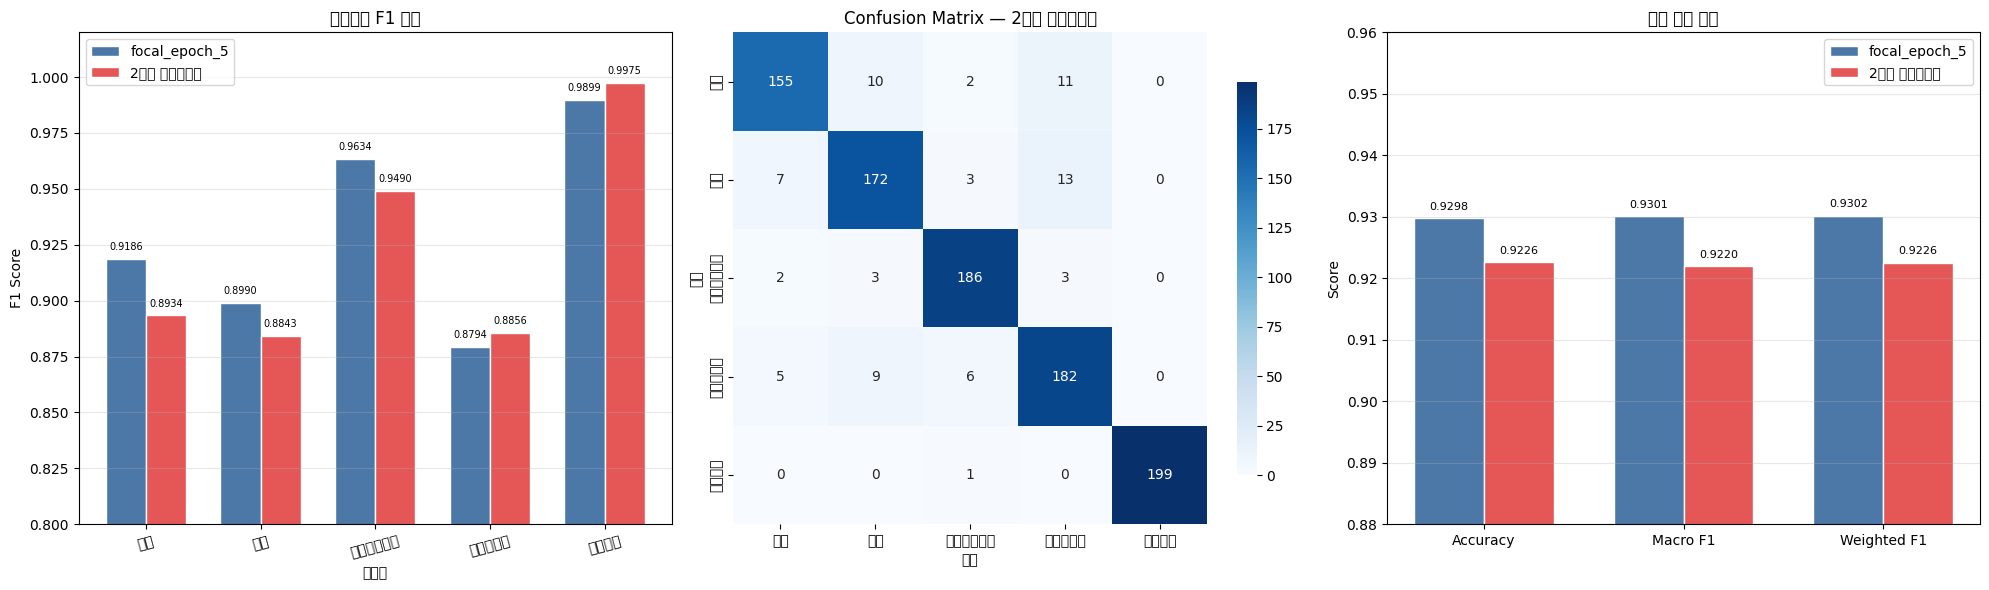

  → 저장: dktc_two_stage_comparison.png


In [11]:
# ============================================================================
# 09. 시각화
# ============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
 
# --- 한글 폰트 ---
font_candidates = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
]
font_path = None
for fc in font_candidates:
    if os.path.exists(fc):
        font_path = fc
        break
if font_path:
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
else:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
 
 
# ============================================================================
# (a) 클래스별 F1 비교 — 단일 vs 파이프라인
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
 
ax = axes[0]
x = np.arange(len(LABEL_NAMES_5))
width = 0.35
 
ref_f1s = [
    REF_FOCAL_EPOCH5["f1_협박"],
    REF_FOCAL_EPOCH5["f1_갈취"],
    REF_FOCAL_EPOCH5["f1_직장내괴롭힘"],
    REF_FOCAL_EPOCH5["f1_기타괴롭힘"],
    REF_FOCAL_EPOCH5["f1_일반대화"],
]
pipe_f1s = list(pipe_class_f1)
 
bars1 = ax.bar(x - width/2, ref_f1s, width, label="focal_epoch_5", color="#4C78A8", edgecolor="white")
bars2 = ax.bar(x + width/2, pipe_f1s, width, label="2단계 파이프라인", color="#E45756", edgecolor="white")
 
ax.set_xlabel("클래스")
ax.set_ylabel("F1 Score")
ax.set_title("클래스별 F1 비교")
ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES_5, rotation=15)
ax.set_ylim(0.8, 1.02)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
 
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003, f"{h:.4f}",
                ha="center", va="bottom", fontsize=7)
 
 
# ============================================================================
# (b) Confusion Matrix — 2단계 파이프라인
# ============================================================================
ax = axes[1]
sns.heatmap(
    cm_pipe, annot=True, fmt="d", cmap="Blues",
    xticklabels=LABEL_NAMES_5, yticklabels=LABEL_NAMES_5,
    ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_xlabel("예측")
ax.set_ylabel("실제")
ax.set_title("Confusion Matrix — 2단계 파이프라인")
 
 
# ============================================================================
# (c) 종합 지표 비교 바 차트
# ============================================================================
ax = axes[2]
metrics_names = ["Accuracy", "Macro F1", "Weighted F1"]
ref_vals = [REF_FOCAL_EPOCH5["accuracy"], REF_FOCAL_EPOCH5["f1_macro"], REF_FOCAL_EPOCH5["f1_weighted"]]
pipe_vals = [pipe_acc, pipe_f1m, pipe_f1w]
 
x2 = np.arange(len(metrics_names))
bars1 = ax.bar(x2 - width/2, ref_vals, width, label="focal_epoch_5", color="#4C78A8", edgecolor="white")
bars2 = ax.bar(x2 + width/2, pipe_vals, width, label="2단계 파이프라인", color="#E45756", edgecolor="white")
 
ax.set_ylabel("Score")
ax.set_title("종합 지표 비교")
ax.set_xticks(x2)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0.88, 0.96)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
 
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.001, f"{h:.4f}",
                ha="center", va="bottom", fontsize=8)
 
plt.tight_layout()
plt.savefig("dktc_two_stage_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → 저장: dktc_two_stage_comparison.png")

In [12]:
# ============================================================================
# 10. 성공/실패 기준 판정
# ============================================================================
print("\n" + "=" * 70)
print(" 2단계 분류 프로토타입 — 성공/실패 기준 판정")
print("=" * 70)
 
# 런북 Section 8.3A 평가 기준 체크
criteria_met = 0
 
# 기준 1: 최종 5-class Macro F1 ≥ 기존 best
c1 = pipe_f1m >= REF_FOCAL_EPOCH5["f1_macro"]
criteria_met += c1
print(f"\n✅ 기준 1: Macro F1 ≥ 기존 best" if c1 else f"\n❌ 기준 1: Macro F1 ≥ 기존 best")
print(f"   파이프라인: {pipe_f1m:.4f}  vs  focal_epoch_5: {REF_FOCAL_EPOCH5['f1_macro']:.4f}")
 
# 기준 2: 기타괴롭힘, 갈취, 협박 중 최소 2개 클래스 F1 개선
improved_classes = []
target_classes = [
    ("협박", 0, REF_FOCAL_EPOCH5["f1_협박"]),
    ("갈취", 1, REF_FOCAL_EPOCH5["f1_갈취"]),
    ("기타괴롭힘", 3, REF_FOCAL_EPOCH5["f1_기타괴롭힘"]),
]
for name, idx, ref_val in target_classes:
    if pipe_class_f1[idx] > ref_val:
        improved_classes.append(name)
 
c2 = len(improved_classes) >= 2
criteria_met += c2
print(f"\n✅ 기준 2: 타겟 3개 클래스 중 ≥2개 F1 개선" if c2 else f"\n❌ 기준 2: 타겟 3개 클래스 중 ≥2개 F1 개선")
print(f"   개선된 클래스: {improved_classes if improved_classes else '없음'}")
for name, idx, ref_val in target_classes:
    delta = pipe_class_f1[idx] - ref_val
    sign = "+" if delta >= 0 else ""
    print(f"   {name}: {pipe_class_f1[idx]:.4f} (ref {ref_val:.4f}, {sign}{delta:.4f})")
 
# 기준 3: 타겟 혼동축 오분류 총합 감소
c3 = total_pipe < total_ref
criteria_met += c3
print(f"\n✅ 기준 3: 타겟 혼동축 오분류 감소" if c3 else f"\n❌ 기준 3: 타겟 혼동축 오분류 감소")
print(f"   파이프라인: {total_pipe}  vs  focal_epoch_5: {total_ref} (보수적 집계)")
 
# 기준 4: 일반대화 성능 유지
normal_drop = REF_FOCAL_EPOCH5["f1_일반대화"] - pipe_class_f1[4]
c4 = normal_drop < 0.02  # 2%p 미만 하락이면 유지로 판단
criteria_met += c4
print(f"\n✅ 기준 4: 일반대화 성능 유지 (하락 < 2%p)" if c4 else f"\n❌ 기준 4: 일반대화 성능 유지 (하락 < 2%p)")
print(f"   파이프라인: {pipe_class_f1[4]:.4f}  vs  ref: {REF_FOCAL_EPOCH5['f1_일반대화']:.4f} (Δ={-normal_drop:+.4f})")
 
 
# --- 종합 판정 ---
print("\n" + "=" * 70)
if criteria_met >= 2:
    print(f"✅ 종합 판정: 후보 유지 (충족 {criteria_met}/4)")
    print("   → 2단계 분류 파이프라인을 제출 후보로 유지")
else:
    print(f"❌ 종합 판정: 우선순위 하향 (충족 {criteria_met}/4)")
    print("   → 단일 5-class focal_epoch_5가 현 시점 최선")
print("=" * 70)
 
 
# --- 실패 기준 체크 ---
print("\n[실패 기준 체크]")
fail_flags = []
 
# 실패 1: Stage 1에서 괴롭힘 미탐지 비율 높음
harm_miss_rate = fn_count / (labels_s1 == 1).sum() if (labels_s1 == 1).sum() > 0 else 0
if harm_miss_rate > 0.05:
    fail_flags.append(f"Stage 1 괴롭힘 미탐지율 {harm_miss_rate:.1%} > 5%")
    print(f"  ⚠️ Stage 1 괴롭힘 미탐지율: {harm_miss_rate:.1%}")
else:
    print(f"  ✓ Stage 1 괴롭힘 미탐지율: {harm_miss_rate:.1%} (양호)")
 
# 실패 2: Macro F1 확실히 낮음
if pipe_f1m < REF_FOCAL_EPOCH5["f1_macro"] - 0.005:
    fail_flags.append(f"Macro F1 {pipe_f1m:.4f} < {REF_FOCAL_EPOCH5['f1_macro'] - 0.005:.4f}")
    print(f"  ⚠️ Macro F1 확실히 낮음: {pipe_f1m:.4f}")
else:
    print(f"  ✓ Macro F1: {pipe_f1m:.4f} (기존 대비 큰 하락 없음)")
 
# 실패 3: 일반대화 깨짐
if normal_drop > 0.03:
    fail_flags.append(f"일반대화 F1 하락 {normal_drop:.4f} > 0.03")
    print(f"  ⚠️ 일반대화 F1 하락: {normal_drop:.4f}")
else:
    print(f"  ✓ 일반대화 F1 하락: {normal_drop:.4f} (양호)")
 
if fail_flags:
    print(f"\n  → 실패 플래그 {len(fail_flags)}개: 우선순위 하향 근거")
    for ff in fail_flags:
        print(f"    - {ff}")
else:
    print(f"\n  → 실패 플래그 없음")


 2단계 분류 프로토타입 — 성공/실패 기준 판정

❌ 기준 1: Macro F1 ≥ 기존 best
   파이프라인: 0.9220  vs  focal_epoch_5: 0.9301

❌ 기준 2: 타겟 3개 클래스 중 ≥2개 F1 개선
   개선된 클래스: ['기타괴롭힘']
   협박: 0.8934 (ref 0.9186, -0.0252)
   갈취: 0.8843 (ref 0.8990, -0.0147)
   기타괴롭힘: 0.8856 (ref 0.8794, +0.0062)

❌ 기준 3: 타겟 혼동축 오분류 감소
   파이프라인: 48  vs  focal_epoch_5: 38 (보수적 집계)

✅ 기준 4: 일반대화 성능 유지 (하락 < 2%p)
   파이프라인: 0.9975  vs  ref: 0.9899 (Δ=+0.0076)

❌ 종합 판정: 우선순위 하향 (충족 1/4)
   → 단일 5-class focal_epoch_5가 현 시점 최선

[실패 기준 체크]
  ✓ Stage 1 괴롭힘 미탐지율: 0.0% (양호)
  ⚠️ Macro F1 확실히 낮음: 0.9220
  ✓ 일반대화 F1 하락: -0.0076 (양호)

  → 실패 플래그 1개: 우선순위 하향 근거
    - Macro F1 0.9220 < 0.9251


In [14]:
# ============================================================================
# 11. 결과 저장
# ============================================================================

# --- 비교 테이블 CSV ---
comparison.to_csv("dktc_two_stage_comparison.csv", index=False)

def to_serializable(obj):
    """numpy/pandas 계열 타입을 JSON 저장 가능한 기본 파이썬 타입으로 변환"""
    import numpy as np

    if isinstance(obj, dict):
        return {str(k): to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    elif isinstance(obj, tuple):
        return [to_serializable(v) for v in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.bool_):
        return bool(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj

# --- 파이프라인 상세 기록 JSON ---
summary = {
    "stage1": {
        "task": "binary (일반대화 vs 괴롭힘)",
        "epochs": 3,
        "lr": 2e-5,
        "loss": "CrossEntropy (weighted)",
        "accuracy": round(acc_s1, 4),
        "f1_macro": round(f1_macro_s1, 4),
        "recall_harm": round(recall_harm_s1, 4),
        "recall_normal": round(recall_norm_s1, 4),
        "harm_miss_count": int(fn_count),
        "train_time_sec": round(time_s1, 1),
    },
    "stage2": {
        "task": "4-class harm (협박/갈취/직장내괴롭힘/기타괴롭힘)",
        "epochs": 5,
        "lr": 2e-5,
        "loss": "Focal Loss (gamma=2.0, class_weight=True)",
        "f1_macro_standalone": round(f1_macro_s2_standalone, 4),
        "train_time_sec": round(time_s2, 1),
    },
    "pipeline_5class": {
        "accuracy": round(pipe_acc, 4),
        "f1_macro": round(pipe_f1m, 4),
        "f1_weighted": round(pipe_f1w, 4),
        "class_f1": {name: round(f1, 4) for name, f1 in zip(LABEL_NAMES_5, pipe_class_f1)},
        "wrong_count": int(wrong_pipe),
    },
    "reference_focal_epoch_5": REF_FOCAL_EPOCH5,
    "criteria_met": criteria_met,
    "fail_flags": fail_flags,
    "total_train_time_sec": round(time_s1 + time_s2, 1),
}

summary = to_serializable(summary)

with open("dktc_two_stage_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("dktc_two_stage_comparison.csv 저장 완료")
print("dktc_two_stage_summary.json 저장 완료")
print(f"\n총 소요 시간: {time_s1 + time_s2:.0f}초 ({(time_s1 + time_s2)/60:.1f}분)")
print(f"  Stage 1: {time_s1:.0f}초")
print(f"  Stage 2: {time_s2:.0f}초")

dktc_two_stage_comparison.csv 저장 완료
dktc_two_stage_summary.json 저장 완료

총 소요 시간: 283초 (4.7분)
  Stage 1: 115초
  Stage 2: 168초


In [17]:
# ============================================================================
# 12. 복구용 최종 평가 셀 (append-only)
# - Stage 1/Stage 2 예측이 이미 끝난 상태에서 최종 5-class 성능 재계산
# - baseline(focal_epoch_5) 대비 비교
# - JSON/CSV 안전 저장
# ============================================================================

import json
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print("\n" + "=" * 70)
print(" 복구용 최종 평가 셀")
print("=" * 70)

# ---------------------------------------------------------------------------
# 0) 필수 변수 존재 확인
# ---------------------------------------------------------------------------
required_vars = [
    "val_df", "preds_s1", "preds_s2_full",
    "LABEL_NAMES_5"
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(f"필수 변수가 없습니다: {missing_vars}")

# baseline 참조값이 기존 셀에서 안 살아있으면 여기서 보강
if "REF_FOCAL_EPOCH5" not in globals():
    REF_FOCAL_EPOCH5 = {
        "model_name": "focal_epoch_5",
        "accuracy": 0.9298,
        "f1_macro": 0.9301,
        "f1_weighted": 0.9302,
        "f1_협박": 0.9186,
        "f1_갈취": 0.8990,
        "f1_직장내괴롭힘": 0.9634,
        "f1_기타괴롭힘": 0.8794,
        "f1_일반대화": 0.9899,
        "wrong_count": 68,
    }

assert len(preds_s1) == len(val_df), f"preds_s1 길이 불일치: {len(preds_s1)} vs {len(val_df)}"
assert len(preds_s2_full) == len(val_df), f"preds_s2_full 길이 불일치: {len(preds_s2_full)} vs {len(val_df)}"

# ---------------------------------------------------------------------------
# 1) 최종 5-class 합성
# Stage 1: 0=일반대화, 1=괴롭힘
# Stage 2: 0~3 = 협박/갈취/직장내괴롭힘/기타괴롭힘
# 최종: Stage1=0 이면 4(일반대화), 아니면 Stage2 예측 사용
# ---------------------------------------------------------------------------
labels_5class = val_df["label"].astype(int).values

final_preds_pipeline_recalc = np.where(
    np.asarray(preds_s1).astype(int) == 0,
    4,
    np.asarray(preds_s2_full).astype(int)
)

# sanity check
assert np.all(np.isin(final_preds_pipeline_recalc, [0, 1, 2, 3, 4])), \
    f"최종 예측값에 허용 범위 밖 클래스가 있습니다: {np.unique(final_preds_pipeline_recalc)}"

# ---------------------------------------------------------------------------
# 2) 최종 5-class 성능 계산
# ---------------------------------------------------------------------------
pipe_acc_re = accuracy_score(labels_5class, final_preds_pipeline_recalc)
pipe_f1m_re = f1_score(labels_5class, final_preds_pipeline_recalc, average="macro")
pipe_f1w_re = f1_score(labels_5class, final_preds_pipeline_recalc, average="weighted")
pipe_class_f1_re = f1_score(
    labels_5class, final_preds_pipeline_recalc,
    average=None, labels=[0, 1, 2, 3, 4]
)

print("\n[최종 5-class 성능 — 재계산]")
print(f"  Accuracy:     {pipe_acc_re:.4f}")
print(f"  Macro F1:     {pipe_f1m_re:.4f}")
print(f"  Weighted F1:  {pipe_f1w_re:.4f}")

print("\n[Classification Report — 재계산]")
print(classification_report(
    labels_5class,
    final_preds_pipeline_recalc,
    target_names=LABEL_NAMES_5,
    digits=4
))

# ---------------------------------------------------------------------------
# 3) baseline(focal_epoch_5) 대비 비교표
# ---------------------------------------------------------------------------
comparison_re = pd.DataFrame([
    {
        "model": REF_FOCAL_EPOCH5["model_name"],
        "accuracy": REF_FOCAL_EPOCH5["accuracy"],
        "f1_macro": REF_FOCAL_EPOCH5["f1_macro"],
        "f1_weighted": REF_FOCAL_EPOCH5["f1_weighted"],
        "wrong_count": int(REF_FOCAL_EPOCH5.get(
        "wrong_count",
        round((1.0 - float(REF_FOCAL_EPOCH5["accuracy"])) * len(labels_5class))
    )
),
    },
    {
        "model": "two_stage_pipeline_recalc",
        "accuracy": pipe_acc_re,
        "f1_macro": pipe_f1m_re,
        "f1_weighted": pipe_f1w_re,
        "wrong_count": int((labels_5class != final_preds_pipeline_recalc).sum()),
    }
])

print("\n[비교표]")
print(comparison_re.to_string(index=False))

# 클래스별 F1 비교표
ref_class_f1 = [
    REF_FOCAL_EPOCH5["f1_협박"],
    REF_FOCAL_EPOCH5["f1_갈취"],
    REF_FOCAL_EPOCH5["f1_직장내괴롭힘"],
    REF_FOCAL_EPOCH5["f1_기타괴롭힘"],
    REF_FOCAL_EPOCH5["f1_일반대화"],
]

class_f1_compare_re = pd.DataFrame({
    "class": LABEL_NAMES_5,
    "focal_epoch_5": ref_class_f1,
    "two_stage_pipeline": pipe_class_f1_re,
    "delta": np.asarray(pipe_class_f1_re) - np.asarray(ref_class_f1)
})

print("\n[클래스별 F1 비교]")
print(class_f1_compare_re.to_string(index=False))

# ---------------------------------------------------------------------------
# 4) 혼동행렬 + 오분류 패턴
# ---------------------------------------------------------------------------
cm_re = confusion_matrix(labels_5class, final_preds_pipeline_recalc, labels=[0, 1, 2, 3, 4])
cm_re_df = pd.DataFrame(cm_re, index=LABEL_NAMES_5, columns=LABEL_NAMES_5)

print("\n[Confusion Matrix]")
print(cm_re_df)

wrong_mask_re = labels_5class != final_preds_pipeline_recalc
wrong_count_re = int(wrong_mask_re.sum())

print(f"\n[오분류 수] {wrong_count_re} / {len(labels_5class)} ({wrong_count_re/len(labels_5class)*100:.2f}%)")

if wrong_count_re > 0:
    wrong_pairs_re = list(zip(labels_5class[wrong_mask_re], final_preds_pipeline_recalc[wrong_mask_re]))
    print("\n[오분류 패턴 Top 15]")
    for (true_cls, pred_cls), cnt in Counter(wrong_pairs_re).most_common(15):
        print(f"  {LABEL_NAMES_5[true_cls]:10s} → {LABEL_NAMES_5[pred_cls]:10s}: {cnt}건")

# ---------------------------------------------------------------------------
# 5) 성공/실패 기준(보수적 재판정)
# 주의: 혼동축 총합 비교는 baseline 전체 confusion matrix가 없어서 '참고'만 출력
# ---------------------------------------------------------------------------
improved_classes_re = []
for cls_name, idx, ref_val in [
    ("협박", 0, REF_FOCAL_EPOCH5["f1_협박"]),
    ("갈취", 1, REF_FOCAL_EPOCH5["f1_갈취"]),
    ("기타괴롭힘", 3, REF_FOCAL_EPOCH5["f1_기타괴롭힘"]),
]:
    if pipe_class_f1_re[idx] > ref_val:
        improved_classes_re.append(cls_name)

# 일반대화 성능 체크
normal_ref = REF_FOCAL_EPOCH5["f1_일반대화"]
normal_pipe = pipe_class_f1_re[4]
normal_drop = float(normal_pipe - normal_ref)

success_flags_re = {
    "macro_f1_ge_best": bool(pipe_f1m_re >= REF_FOCAL_EPOCH5["f1_macro"]),
    "target_3class_improved_at_least_2": bool(len(improved_classes_re) >= 2),
    # baseline 전체 confusion matrix가 없으므로 hard criterion으로 쓰지 않음
    "normal_class_not_materially_worse": bool(normal_drop >= -0.0030),
}

criteria_met_re = int(sum(success_flags_re.values()))

print("\n[재판정]")
for k, v in success_flags_re.items():
    print(f"  {k}: {v}")
print(f"  criteria_met_re: {criteria_met_re} / {len(success_flags_re)}")
print(f"  improved_target_classes: {improved_classes_re if improved_classes_re else '없음'}")

# ---------------------------------------------------------------------------
# 6) JSON 안전 저장
# ---------------------------------------------------------------------------
def to_serializable(obj):
    if isinstance(obj, dict):
        return {str(k): to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    elif isinstance(obj, tuple):
        return [to_serializable(v) for v in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.bool_):
        return bool(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj

summary_re = {
    "pipeline_5class_recalc": {
        "accuracy": pipe_acc_re,
        "f1_macro": pipe_f1m_re,
        "f1_weighted": pipe_f1w_re,
        "class_f1": {name: f1 for name, f1 in zip(LABEL_NAMES_5, pipe_class_f1_re)},
        "wrong_count": wrong_count_re,
    },
    "reference_focal_epoch_5": REF_FOCAL_EPOCH5,
    "success_flags_recalc": success_flags_re,
    "criteria_met_recalc": criteria_met_re,
    "improved_target_classes": improved_classes_re,
    "note": "target confusion-axis total은 baseline 전체 confusion matrix 부재로 참고 출력만 가능",
}

comparison_re.to_csv("dktc_two_stage_comparison_recalc.csv", index=False)
class_f1_compare_re.to_csv("dktc_two_stage_class_f1_compare_recalc.csv", index=False)
cm_re_df.to_csv("dktc_two_stage_confusion_matrix_recalc.csv", encoding="utf-8-sig")

with open("dktc_two_stage_summary_recalc.json", "w", encoding="utf-8") as f:
    json.dump(to_serializable(summary_re), f, indent=2, ensure_ascii=False)

print("\n저장 완료:")
print(" - dktc_two_stage_comparison_recalc.csv")
print(" - dktc_two_stage_class_f1_compare_recalc.csv")
print(" - dktc_two_stage_confusion_matrix_recalc.csv")
print(" - dktc_two_stage_summary_recalc.json")


 복구용 최종 평가 셀

[최종 5-class 성능 — 재계산]
  Accuracy:     0.9226
  Macro F1:     0.9220
  Weighted F1:  0.9226

[Classification Report — 재계산]
              precision    recall  f1-score   support

          협박     0.9172    0.8708    0.8934       178
          갈취     0.8866    0.8821    0.8843       195
      직장내괴롭힘     0.9394    0.9588    0.9490       194
       기타괴롭힘     0.8708    0.9010    0.8856       202
        일반대화     1.0000    0.9950    0.9975       200

    accuracy                         0.9226       969
   macro avg     0.9228    0.9215    0.9220       969
weighted avg     0.9229    0.9226    0.9226       969


[비교표]
                     model  accuracy  f1_macro  f1_weighted  wrong_count
focal_epoch_5 (단일 5-class)  0.929800  0.930100     0.930200           68
 two_stage_pipeline_recalc  0.922601  0.921962     0.922563           75

[클래스별 F1 비교]
 class  focal_epoch_5  two_stage_pipeline     delta
    협박         0.9186            0.893372 -0.025228
    갈취         0.8990         